# ResNet-18 -> SmallCNN Knowledge Distillation -- CIFAR-10

Trains a SmallCNN student (170K parameters) to mimic a ResNet-18 teacher (11.17M parameters) using the
distillation objective of Hinton et al. (2015). Runs both distillation and a CE-only baseline
sequentially for a fair comparison.

**Setup:** upload `resnet.py` and `best_resnet18_cifar10 (1).pth` via the Kaggle data panel before running.

Reference: Hinton, Vinyals & Dean (2015) -- *Distilling the Knowledge in a Neural Network*
https://arxiv.org/abs/1503.02531

## 1. Imports and config

In [9]:
import os
for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        if f.endswith(".py") or f.endswith(".pth"):
            print(os.path.join(root, f))

/kaggle/input/datasets/mendelowitzadi/resent-input/best_resnet18_cifar10 (1).pth
/kaggle/input/datasets/mendelowitzadi/resent-input/resnet.py


In [17]:
import logging
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

TEACHER_CHECKPOINT = "/kaggle/input/datasets/mendelowitzadi/resent-input/best_resnet18_cifar10 (1).pth"
DATA_DIR = "/kaggle/working/data"
CHECKPOINT_DIR = Path("/kaggle/working/checkpoints/distillation")
PLOT_DIR = Path("/kaggle/working/plots/distillation")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2470, 0.2435, 0.2616)
BATCH_SIZE   = 128
EPOCHS       = 30
LR           = 1e-3
TEMPERATURE  = 4.0
ALPHA        = 0.3   # weight on KL term; (1-ALPHA) weights CE

logging.basicConfig(level=logging.INFO, format="%(asctime)s  %(message)s", datefmt="%d/%m/%Y %H:%M:%S")
logger = logging.getLogger(__name__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")

Device: cuda
PyTorch: 2.10.0+cu128


## 2. Student architecture

In [19]:
class SmallCNN(nn.Module):
    """
    Lightweight 3-conv-block CNN for CIFAR-10 (32x32 input).

    Architecture:
        Block 1: Conv(3->32)  + BN + ReLU + MaxPool(2) -> 16x16
        Block 2: Conv(32->64) + BN + ReLU + MaxPool(2) ->  8x8
        Block 3: Conv(64->256)+ BN + ReLU + AdaptiveAvgPool(1) -> 1x1
        Linear(256, num_classes)

    ~170K parameters -- 65x smaller than ResNet-18.
    """
    def __init__(self, num_classes: int = 10) -> None:
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Linear(256, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.features(x).flatten(1))


def build_student(num_classes: int = 10) -> nn.Module:
    return SmallCNN(num_classes=num_classes)


_s = build_student()
print(f"SmallCNN parameters: {sum(p.numel() for p in _s.parameters()):,}")
del _s

SmallCNN parameters: 170,378


## 3. Loss function

In [20]:
def distillation_loss(
    student_logits: torch.Tensor,
    teacher_logits: torch.Tensor,
    labels: torch.Tensor,
    T: float,
    alpha: float,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Combined KD + CE loss (Hinton et al. 2015).

    L = alpha * T^2 * KL(softmax(z_t/T) || softmax(z_s/T)) + (1-alpha) * CE(z_s, y)

    The T^2 factor restores gradient magnitudes after dividing logits by T,
    keeping alpha a stable hyperparameter across temperature values.

    Returns:
        (combined_loss, kd_loss, ce_loss)
    """
    kd = (
        F.kl_div(
            F.log_softmax(student_logits / T, dim=1),
            F.softmax(teacher_logits / T, dim=1),
            reduction="batchmean",
        )
        * (T ** 2)
    )
    ce = F.cross_entropy(student_logits, labels)
    return alpha * kd + (1 - alpha) * ce, kd, ce

print("Loss function defined.")

Loss function defined.


## 4. Data loaders

In [21]:
def get_cifar10_loaders() -> tuple[DataLoader, DataLoader]:
    """Return (train_loader, val_loader) for CIFAR-10."""
    train_transform = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
    ])
    val_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
    ])
    train_ds = datasets.CIFAR10(DATA_DIR, train=True,  download=True, transform=train_transform)
    val_ds   = datasets.CIFAR10(DATA_DIR, train=False, download=True, transform=val_transform)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    return train_loader, val_loader


train_loader, val_loader = get_cifar10_loaders()
print(f"Train batches: {len(train_loader)}  Val batches: {len(val_loader)}")

100%|██████████| 170M/170M [00:04<00:00, 37.6MB/s] 


Train batches: 391  Val batches: 79


## 5. Teacher loading

In [23]:
def load_teacher(checkpoint_path: str) -> nn.Module:
    """Load CIFAR-10 adapted ResNet-18 (3x3 stem, no maxpool), frozen."""
    from torchvision.models import resnet18
    model = resnet18(weights=None, num_classes=10)
    model.conv1   = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    state = torch.load(checkpoint_path, map_location=device, weights_only=False)
    
    state = {
        k.replace("shortcut", "downsample"): v
        for k, v in state.items()
        if "num_batches_tracked" not in k
    }
    model.load_state_dict(state)
    model.eval()
    for p in model.parameters():
        p.requires_grad = False
    return model.to(device)


teacher = load_teacher(TEACHER_CHECKPOINT)
print(f"Teacher (ResNet-18): {sum(p.numel() for p in teacher.parameters()):,} parameters")

Teacher (ResNet-18): 11,173,962 parameters


## 6. Training utilities

In [24]:
def _train_epoch_distill(
    student: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
) -> tuple[float, float, float, float]:
    """One distillation epoch. Returns (combined, kd, ce, accuracy)."""
    student.train()
    total_combined = total_kd = total_ce = correct = n = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        with torch.no_grad():
            teacher_logits = teacher(images)
        student_logits = student(images)
        loss, kd, ce = distillation_loss(student_logits, teacher_logits, labels, TEMPERATURE, ALPHA)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        bs = images.size(0)
        total_combined += bs * loss.item()
        total_kd       += bs * kd.item()
        total_ce       += bs * ce.item()
        correct        += (student_logits.argmax(dim=1) == labels).sum().item()
        n              += bs

    return total_combined / n, total_kd / n, total_ce / n, correct / n


def _train_epoch_baseline(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
) -> tuple[float, float]:
    """One CE epoch. Returns (ce_loss, accuracy)."""
    model.train()
    total_ce = correct = n = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss   = F.cross_entropy(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        bs = images.size(0)
        total_ce += bs * loss.item()
        correct  += (logits.argmax(dim=1) == labels).sum().item()
        n        += bs

    return total_ce / n, correct / n


def _val_epoch(model: nn.Module, loader: DataLoader) -> tuple[float, float]:
    """Validation pass. Returns (ce_loss, accuracy)."""
    model.eval()
    total_ce = correct = n = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            loss   = F.cross_entropy(logits, labels)
            bs     = images.size(0)
            total_ce += bs * loss.item()
            correct  += (logits.argmax(dim=1) == labels).sum().item()
            n        += bs

    return total_ce / n, correct / n

print("Training utilities defined.")

Training utilities defined.


## 7. Run distillation

In [25]:
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

student_distill  = build_student().to(device)
optimizer_d      = torch.optim.Adam(student_distill.parameters(), lr=LR)
scheduler_d      = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_d, T_max=EPOCHS)

history_distill: dict[str, list[float]] = {
    "train_loss": [], "kd_loss": [], "ce_loss": [], "val_loss": [], "val_acc": []
}
best_val_acc_d = 0.0

logger.info("Distillation: T=%.1f  alpha=%.2f  epochs=%d", TEMPERATURE, ALPHA, EPOCHS)

for epoch in range(1, EPOCHS + 1):
    tr_loss, kd_loss, ce_loss, _ = _train_epoch_distill(student_distill, train_loader, optimizer_d)
    val_loss, val_acc             = _val_epoch(student_distill, val_loader)
    scheduler_d.step()

    history_distill["train_loss"].append(tr_loss)
    history_distill["kd_loss"].append(kd_loss)
    history_distill["ce_loss"].append(ce_loss)
    history_distill["val_loss"].append(val_loss)
    history_distill["val_acc"].append(val_acc)

    logger.info(
        "Distill [%d/%d]  train=%.4f  kd=%.4f  ce=%.4f  val_acc=%.2f%%",
        epoch, EPOCHS, tr_loss, kd_loss, ce_loss, val_acc * 100,
    )

    if val_acc > best_val_acc_d:
        best_val_acc_d = val_acc
        torch.save(
            {"epoch": epoch, "val_acc": val_acc,
             "model_state_dict": student_distill.state_dict(),
             "optimizer_state_dict": optimizer_d.state_dict()},
            CHECKPOINT_DIR / "best_student_distill.pth",
        )

logger.info("Distillation complete. Best val_acc=%.2f%%", best_val_acc_d * 100)

01/04/2026 12:13:05  Distillation: T=4.0  alpha=0.30  epochs=30
01/04/2026 12:13:22  Distill [1/30]  train=3.9800  kd=9.6617  ce=1.5450  val_acc=44.51%
01/04/2026 12:13:37  Distill [2/30]  train=3.2358  kd=7.7679  ce=1.2935  val_acc=52.36%
01/04/2026 12:13:51  Distill [3/30]  train=2.9591  kd=7.0944  ce=1.1868  val_acc=56.83%
01/04/2026 12:14:06  Distill [4/30]  train=2.7827  kd=6.6674  ce=1.1178  val_acc=58.75%
01/04/2026 12:14:22  Distill [5/30]  train=2.6407  kd=6.3404  ce=1.0552  val_acc=62.60%
01/04/2026 12:14:37  Distill [6/30]  train=2.5196  kd=6.0564  ce=1.0039  val_acc=63.12%
01/04/2026 12:14:53  Distill [7/30]  train=2.4276  kd=5.8378  ce=0.9661  val_acc=61.26%
01/04/2026 12:15:09  Distill [8/30]  train=2.3396  kd=5.6366  ce=0.9266  val_acc=67.53%
01/04/2026 12:15:26  Distill [9/30]  train=2.2524  kd=5.4370  ce=0.8875  val_acc=65.50%
01/04/2026 12:15:43  Distill [10/30]  train=2.1908  kd=5.2868  ce=0.8639  val_acc=69.70%
01/04/2026 12:15:59  Distill [11/30]  train=2.1236  kd=

## 8. Run CE baseline

In [26]:
student_baseline = build_student().to(device)
optimizer_b      = torch.optim.Adam(student_baseline.parameters(), lr=LR)
scheduler_b      = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_b, T_max=EPOCHS)

history_baseline: dict[str, list[float]] = {"train_loss": [], "val_loss": [], "val_acc": []}
best_val_acc_b = 0.0

logger.info("CE baseline: epochs=%d", EPOCHS)

for epoch in range(1, EPOCHS + 1):
    tr_loss, _ = _train_epoch_baseline(student_baseline, train_loader, optimizer_b)
    val_loss, val_acc = _val_epoch(student_baseline, val_loader)
    scheduler_b.step()

    history_baseline["train_loss"].append(tr_loss)
    history_baseline["val_loss"].append(val_loss)
    history_baseline["val_acc"].append(val_acc)

    logger.info(
        "Baseline [%d/%d]  train=%.4f  val_acc=%.2f%%",
        epoch, EPOCHS, tr_loss, val_acc * 100,
    )

    if val_acc > best_val_acc_b:
        best_val_acc_b = val_acc
        torch.save(
            {"epoch": epoch, "val_acc": val_acc,
             "model_state_dict": student_baseline.state_dict(),
             "optimizer_state_dict": optimizer_b.state_dict()},
            CHECKPOINT_DIR / "best_student_baseline.pth",
        )

logger.info("Baseline complete. Best val_acc=%.2f%%", best_val_acc_b * 100)

01/04/2026 12:21:23  CE baseline: epochs=30
01/04/2026 12:21:35  Baseline [1/30]  train=1.4717  val_acc=47.64%
01/04/2026 12:21:48  Baseline [2/30]  train=1.1908  val_acc=56.35%
01/04/2026 12:22:00  Baseline [3/30]  train=1.0814  val_acc=60.01%
01/04/2026 12:22:12  Baseline [4/30]  train=1.0114  val_acc=57.53%
01/04/2026 12:22:25  Baseline [5/30]  train=0.9504  val_acc=63.76%
01/04/2026 12:22:37  Baseline [6/30]  train=0.9092  val_acc=65.70%
01/04/2026 12:22:49  Baseline [7/30]  train=0.8667  val_acc=66.72%
01/04/2026 12:23:01  Baseline [8/30]  train=0.8343  val_acc=68.17%
01/04/2026 12:23:13  Baseline [9/30]  train=0.8099  val_acc=67.98%
01/04/2026 12:23:25  Baseline [10/30]  train=0.7820  val_acc=69.07%
01/04/2026 12:23:38  Baseline [11/30]  train=0.7589  val_acc=71.99%
01/04/2026 12:23:50  Baseline [12/30]  train=0.7361  val_acc=72.39%
01/04/2026 12:24:02  Baseline [13/30]  train=0.7134  val_acc=69.09%
01/04/2026 12:24:15  Baseline [14/30]  train=0.6976  val_acc=71.74%
01/04/2026 12

## 9. Results summary

In [29]:
best_distill  = max(history_distill["val_acc"]) * 100
best_baseline = max(history_baseline["val_acc"]) * 100
gap           = best_distill - best_baseline

col = 24
print(f"{'Model':<{col}} {'Best val_acc (%)':>16}")
print("-" * (col + 18))
print(f"{'SmallCNN (distilled)':<{col}} {best_distill:>16.2f}")
print(f"{'SmallCNN (CE baseline)':<{col}} {best_baseline:>16.2f}")
print(f"{'Gap':<{col}} {gap:>+16.2f}")

Model                    Best val_acc (%)
------------------------------------------
SmallCNN (distilled)                77.73
SmallCNN (CE baseline)              78.93
Gap                                 -1.20


## 10. Plots

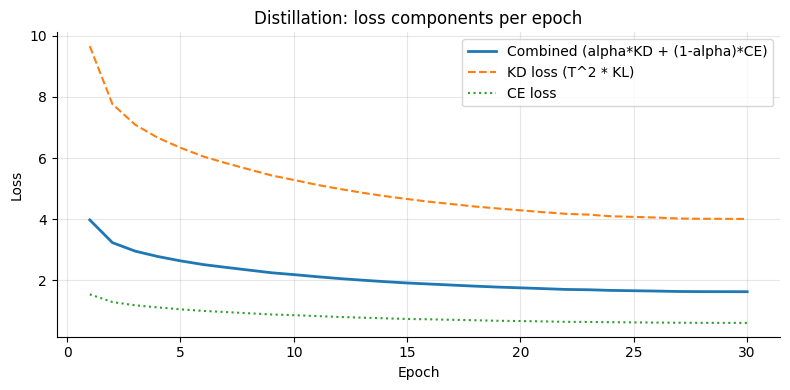

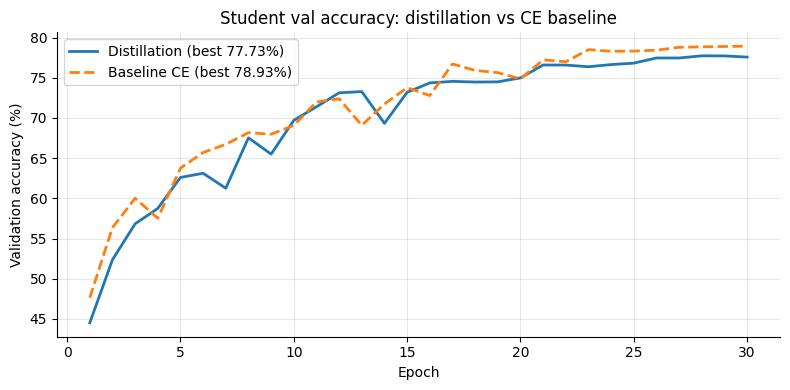

Plots saved to /kaggle/working/plots/distillation


In [30]:
def plot_results() -> None:
    PLOT_DIR.mkdir(parents=True, exist_ok=True)
    ep = range(1, EPOCHS + 1)

    # Loss breakdown
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(ep, history_distill["train_loss"], label="Combined (alpha*KD + (1-alpha)*CE)", linewidth=2)
    ax.plot(ep, history_distill["kd_loss"],    label="KD loss (T^2 * KL)", linestyle="--")
    ax.plot(ep, history_distill["ce_loss"],    label="CE loss", linestyle=":")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title("Distillation: loss components per epoch")
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.savefig(PLOT_DIR / "distill_loss_breakdown.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Val accuracy comparison
    fig, ax = plt.subplots(figsize=(8, 4))
    d_acc = [v * 100 for v in history_distill["val_acc"]]
    b_acc = [v * 100 for v in history_baseline["val_acc"]]
    ax.plot(ep, d_acc, label=f"Distillation (best {max(d_acc):.2f}%)", linewidth=2)
    ax.plot(ep, b_acc, label=f"Baseline CE (best {max(b_acc):.2f}%)", linestyle="--", linewidth=2)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Validation accuracy (%)")
    ax.set_title("Student val accuracy: distillation vs CE baseline")
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.savefig(PLOT_DIR / "val_accuracy_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Plots saved to {PLOT_DIR}")


plot_results()